In [1]:
from datetime import datetime
import os
import pickle
import numpy as np
import pandas as pd

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from generation.utils import plot_iv_surface, repair_edges_local_directional, jitter_grid
from generation.surface_generation import generate_surfaces, SimulationConfig
from models.framework import DeepONet, MLP

# ============================================================
# 1️⃣ Generate synthetic Rough Bergomi IV surfaces
# ============================================================

# cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=1)
# surfaces = generate_surfaces(
#     num_sets=1,
#     forward_curves_per_set=10,
#     cfg=cfg,
#     seed=4235,
#     randomize_grid=False,
# )


SAVE_ROOT = "data/longrun"
surfaces = []

# List and sort all batch files (batch_0000.pkl, batch_0001.pkl, ...)
batch_files = sorted([
    f for f in os.listdir(SAVE_ROOT)
    if f.startswith("batch_") and f.endswith(".pkl")
])

# print(f"Found {len(batch_files)} batch files.")

for fname in batch_files:
    path = os.path.join(SAVE_ROOT, fname)
    try:
        with open(path, "rb") as f:
            data = pickle.load(f)
            # If each file stores {"surfaces": [...]} dicts:
            if isinstance(data, dict) and "surfaces" in data:
                surfaces.extend(data["surfaces"])
            # Or if it’s already a list:
            elif isinstance(data, list):
                surfaces.extend(data)
            else:
                print(f"⚠️ Unrecognized format in {fname}")
        print(f"Loaded {fname}")
    except Exception as e:
        print(f"❌ Error loading {fname}: {e}")

print(f"\n✅ Total surfaces loaded: {len(surfaces)}")

for i in surfaces:
    x = i["iv_surface"]
    maturities = np.array(i["grid"]["maturities"])
    strikes = np.array(i["grid"]["strikes"])
    i["iv_surface"] =  repair_edges_local_directional(x, maturities, strikes)

Loaded batch_0000.pkl
Loaded batch_0001.pkl
Loaded batch_0002.pkl
Loaded batch_0003.pkl
Loaded batch_0004.pkl
Loaded batch_0005.pkl
Loaded batch_0006.pkl
Loaded batch_0007.pkl
Loaded batch_0008.pkl
Loaded batch_0009.pkl
Loaded batch_0010.pkl
Loaded batch_0011.pkl
Loaded batch_0012.pkl
Loaded batch_0013.pkl
Loaded batch_0014.pkl
Loaded batch_0015.pkl
Loaded batch_0016.pkl
Loaded batch_0017.pkl
Loaded batch_0018.pkl
Loaded batch_0019.pkl
Loaded batch_0020.pkl
Loaded batch_0021.pkl
Loaded batch_0022.pkl
Loaded batch_0023.pkl
Loaded batch_0024.pkl
Loaded batch_0025.pkl
Loaded batch_0026.pkl
Loaded batch_0027.pkl
Loaded batch_0028.pkl
Loaded batch_0029.pkl
Loaded batch_0030.pkl
Loaded batch_0031.pkl
Loaded batch_0032.pkl
Loaded batch_0033.pkl
Loaded batch_0034.pkl
Loaded batch_0035.pkl
Loaded batch_0036.pkl
Loaded batch_0037.pkl
Loaded batch_0038.pkl
Loaded batch_0039.pkl
Loaded batch_0040.pkl
Loaded batch_0041.pkl
Loaded batch_0042.pkl
Loaded batch_0043.pkl
Loaded batch_0044.pkl
Loaded bat

# Original Fixed Grid Training Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gzip
import matplotlib.ticker as mtick
import time
f = gzip.GzipFile('TrainrBergomiTermStructure.txt.gz', "r")
dat=np.load(f)
print(dat.shape)
xx=dat[:,:11]
yy=dat[:,11:]
print(xx.shape)
strikes=np.array([0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5 ])
maturities=np.array([0.1,0.3,0.6,0.9,1.2,1.5,1.8,2.0 ])
import numpy as np

# Constants from your setup
strikes = np.array([0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5])
maturities = np.array([0.1,0.3,0.6,0.9,1.2,1.5,1.8,2.0])

num_strikes = len(strikes)
num_maturities = len(maturities)
num_samples = len(xx)

surfaces = []

for i in range(num_samples):
    # forward vols (first 8), eta, rho, H
    fwd_vols = xx[i, :8].tolist()
    eta = float(xx[i, 8])
    rho = float(xx[i, 9])
    H   = float(xx[i, 10])

    # reshape yy row into surface (maturities × strikes)
    iv_surface = yy[i].reshape(num_maturities, num_strikes)

    # build the structured dictionary
    surfaces.append({
        "set_id": int(i),
        "fwd_id": int(i),  # or e.g. i // 100 if multiple fwd vols share params
        "params": {
            "eta": eta,
            "rho": rho,
            "H": H,
            "xi0_knots": fwd_vols
        },
        "grid": {
            "strikes": strikes.astype(np.float32),
            "maturities": maturities.astype(np.float32)
        },
        "iv_surface": iv_surface.astype(np.float32)
    })

# optional: check example
print(surfaces[0]["params"])
print(surfaces[0]["iv_surface"].shape)


(80000, 99)
(80000, 11)
{'eta': 1.09063, 'rho': -0.477665, 'H': 0.41078, 'xi0_knots': [0.0989267, 0.13664, 0.138692, 0.137088, 0.103535, 0.0676573, 0.0546302, 0.0185069]}
(8, 11)


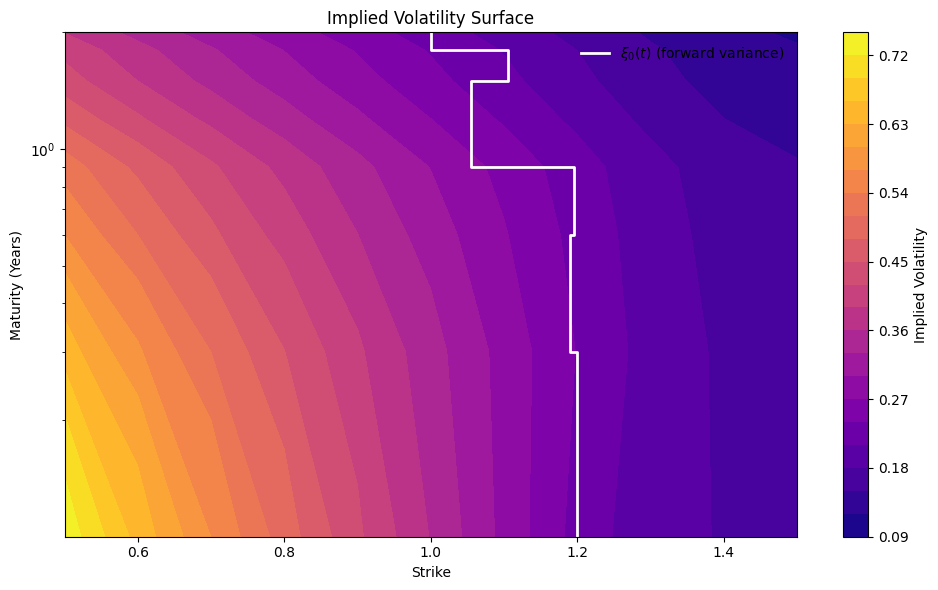

In [8]:
k = 62000
x = surfaces[k]["iv_surface"]
xi0_knots = np.array(surfaces[k]["params"]["xi0_knots"])
maturities = np.array(surfaces[k]["grid"]["maturities"])
strikes = np.array(surfaces[k]["grid"]["strikes"])
# --- reconstruct bin edges for piecewise-constant ξ₀(t) ---
# first edge starts at 0, last one ends at the final maturity
edges = np.concatenate([[0.0], maturities])
plot_iv_surface(
    x, strikes, maturities,
    xi0_knots=xi0_knots,      # K values
    xi0_bin_edges=edges,      # K+1 edges
)



# My Training Data

In [2]:
train_data = surfaces[:110000]
test_data = surfaces[110000:]

# Training splits
mlp_training = [d for d in train_data if d["grid_id"] == 0]
deeponet_training = [d for d in train_data if d["grid_id"] == 1]

# Test split
test_data = [d for d in test_data if d["grid_id"] == 1]

In [3]:
# ============================================================
# Usage Notes (example)
# ============================================================
#DeepONet (with internal scaling):
deeponet_model, train_loader, val_loader, Ks, Ts = DeepONet.from_surfaces(deeponet_training,
    batch_size=8*11*11, val_split=0.2, branch_hidden_dims=(64, 64), trunk_hidden_dims=(64,64), ref_strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5]), ref_maturities= np.array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.1]))
deeponet_model.train_model(train_loader, val_loader, epochs=20, lr_schedule=[(0,0.001),(10,0.0001), (15, 0.00001)])
print("DeepONet Model param counts: ",deeponet_model.count_parameters())
# fig = model.plot_evaluation(test_surfaces[0])
deeponet_eval = deeponet_model.evaluate(test_data, out_dir="deeponet_eval")

Epoch 001 | train_rmse=0.146115, val_rmse=0.072949, lr=1.0e-03, time=54.60s, ETA=17.29 min


Epoch 002 | train_rmse=0.066518, val_rmse=0.060532, lr=1.0e-03, time=48.97s, ETA=15.54 min


Epoch 003 | train_rmse=0.057521, val_rmse=0.056817, lr=1.0e-03, time=48.94s, ETA=14.40 min


Epoch 004 | train_rmse=0.052581, val_rmse=0.050536, lr=1.0e-03, time=49.06s, ETA=13.44 min


Epoch 005 | train_rmse=0.049321, val_rmse=0.048443, lr=1.0e-03, time=49.06s, ETA=12.53 min


...

Epoch 016 | train_rmse=0.035983, val_rmse=0.036181, lr=1.0e-05, time=56.69s, ETA=3.40 min


Epoch 017 | train_rmse=0.035926, val_rmse=0.036141, lr=1.0e-05, time=56.88s, ETA=2.57 min


Epoch 018 | train_rmse=0.035891, val_rmse=0.036108, lr=1.0e-05, time=55.47s, ETA=1.72 min


Epoch 019 | train_rmse=0.035859, val_rmse=0.036077, lr=1.0e-05, time=55.28s, ETA=0.86 min


Epoch 020 | train_rmse=0.035829, val_rmse=0.036048, lr=1.0e-05, time=55.48s, ETA=0.00 min

✅ Training completed in 17.31 min (avg 51.94s per epoch)
Model exported to exports\deeponet_final.json
DeepONet Model param counts:  17792


In [10]:
# MLP (with internal scaling):
mlp_model, train_loader, val_loader, Ks, Ts = MLP.from_surfaces(mlp_training,
    batch_size=32, val_split=0.2, hidden_dims=(64,64,64,64))
mlp_model.train_model(train_loader, val_loader, epochs=50, lr_schedule=[(0,0.001),(30,0.0001), (75, 0.00001)])
print("MLP Model param counts: ",mlp_model.count_parameters())
#fig = model.plot_evaluation(test_surfaces[0])
mlp_eval = mlp_model.evaluate(test_data, out_dir="mlp_eval")

Epoch 001 | train_rmse=0.332539, val_rmse=0.133174, lr=1.0e-03, time=2.35s, ETA=1.92 min


Epoch 002 | train_rmse=0.105852, val_rmse=0.087757, lr=1.0e-03, time=2.26s, ETA=1.84 min


Epoch 003 | train_rmse=0.080210, val_rmse=0.073695, lr=1.0e-03, time=2.14s, ETA=1.76 min


Epoch 004 | train_rmse=0.070313, val_rmse=0.066317, lr=1.0e-03, time=2.14s, ETA=1.70 min


Epoch 005 | train_rmse=0.064647, val_rmse=0.058629, lr=1.0e-03, time=2.16s, ETA=1.66 min


...

Epoch 046 | train_rmse=0.037354, val_rmse=0.037515, lr=1.0e-04, time=2.30s, ETA=0.15 min


Epoch 047 | train_rmse=0.037353, val_rmse=0.037549, lr=1.0e-04, time=2.33s, ETA=0.11 min


Epoch 048 | train_rmse=0.037335, val_rmse=0.037477, lr=1.0e-04, time=2.31s, ETA=0.07 min


Epoch 049 | train_rmse=0.037281, val_rmse=0.037468, lr=1.0e-04, time=2.30s, ETA=0.04 min


Epoch 050 | train_rmse=0.037300, val_rmse=0.037742, lr=1.0e-04, time=2.26s, ETA=0.00 min

✅ Training completed in 1.86 min (avg 2.23s per epoch)
Model exported to exports\mlp_final.json
MLP Model param counts:  17792


# Model Speed Benchmark

Loaded NumPy model from exports/deeponet_final.json (DeepONet)
Loaded NumPy model from exports/mlp_final.json (MLP)
[MLP timing]
  Forward        : 0.0006 s
  Inverse scale  : 0.0000 s
  Reshape        : 0.0000 s
  Interpolation  : 0.0001 s
  Total          : 0.0007 s

[MLP timing]
  Forward        : 0.0006 s
  Inverse scale  : 0.0000 s
  Reshape        : 0.0000 s
  Interpolation  : 0.0000 s
  Total          : 0.0006 s

[MLP timing]
  Forward        : 0.0006 s
  Inverse scale  : 0.0000 s
  Reshape        : 0.0000 s
  Interpolation  : 0.0000 s
  Total          : 0.0006 s

[MLP timing]
  Forward        : 0.0005 s
  Inverse scale  : 0.0000 s
  Reshape        : 0.0000 s
  Interpolation  : 0.0000 s
  Total          : 0.0006 s

[MLP timing]
  Forward        : 0.0005 s
  Inverse scale  : 0.0000 s
  Reshape        : 0.0000 s
  Interpolation  : 0.0000 s
  Total          : 0.0006 s

[MLP timing]
  Forward        : 0.0006 s
  Inverse scale  : 0.0000 s
  Reshape        : 0.0000 s
  Interpolation  

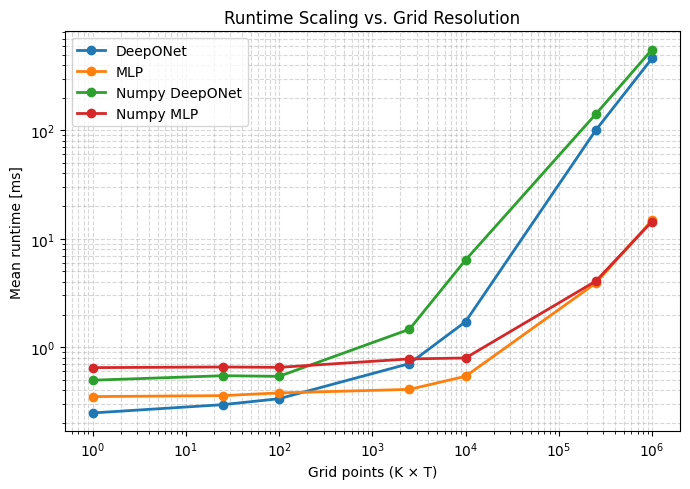

In [9]:
from models.framework import NumpyModel  # assuming your file is saved as models.py
import numpy as np
import time
import matplotlib.pyplot as plt

# --- Load exported MLP model ---
numpy_deeponet_model = NumpyModel.load("exports/deeponet_final.json")
numpy_mlp_model = NumpyModel.load("exports/mlp_final.json")

# ==========================================
# Example grids and parameter variations
# ==========================================
grid_sizes = [1,5, 10, 50, 100, 500, 1000]  # test increasing grid resolutions
param_sets = [
    {"eta": 1.0, "rho": -0.6, "H": 0.1},
    {"eta": 2.0, "rho": -0.3, "H": 0.2},
    {"eta": 0.8, "rho": -0.9, "H": 0.05},
]

# ==========================================
# Models to benchmark
# ==========================================
models = {
    "MLP": mlp_model,
    "Numpy MLP": numpy_mlp_model,   
    "DeepONet": deeponet_model,
    "Numpy DeepONet": numpy_deeponet_model,
    # add others if needed
}

# ==========================================
# Benchmarking loop
# ==========================================
results = []
num_repeats = 10  # run each test multiple times for stable averages

for n in grid_sizes:
    grid = {
        "strikes": np.linspace(0.6, 1.4, n, dtype=np.float32),
        "maturities": np.linspace(0.1, 2.0, n, dtype=np.float32),
    }

    for p in param_sets:
        params = dict(p)
        params["xi0_knots"] = np.full(11, 0.09).tolist()  # ≈ 30% implied vol


        for name, model in models.items():
            # Warmup
            _ = model.predict_surface(params, grid=grid)

            # Timed runs
            times = []
            for _ in range(num_repeats):
                t0 = time.perf_counter()
                _ = model.predict_surface(params, grid=grid)
                t1 = time.perf_counter()
                times.append((t1 - t0) * 1000.0)  # ms

            results.append({
                "model": name,
                "grid_points": n * n,
                "grid_size": n,
                "eta": params["eta"],
                "rho": params["rho"],
                "H": params["H"],
                "time_ms_mean": np.mean(times),
                "time_ms_std": np.std(times),
            })

# ==========================================
# Report and plot
# ==========================================
df = pd.DataFrame(results)
summary = (
    df.groupby(["model", "grid_points"])["time_ms_mean"]
    .mean()
    .reset_index()
)

print("=== Inference Time Summary (ms per surface) ===")
print(summary.pivot(index="grid_points", columns="model", values="time_ms_mean").round(2))

# ==========================================
# Plot runtime scaling (log-log)
# ==========================================
plt.figure(figsize=(7, 5))
for model_name, g in summary.groupby("model"):
    plt.plot(
        g["grid_points"],
        g["time_ms_mean"],
        marker="o",
        label=model_name,
        linewidth=2,
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Grid points (K × T)")
plt.ylabel("Mean runtime [ms]")
plt.title("Runtime Scaling vs. Grid Resolution")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("benchmark_runtime_scaling.png", dpi=200)
plt.show()


In [24]:
results

[{'model': 'MLP',
  'grid_points': 1,
  'grid_size': 1,
  'eta': 1.0,
  'rho': -0.6,
  'H': 0.1,
  'time_ms_mean': np.float64(0.3889599989634007),
  'time_ms_std': np.float64(0.047103508740969295)},
 {'model': 'Numpy MLP',
  'grid_points': 1,
  'grid_size': 1,
  'eta': 1.0,
  'rho': -0.6,
  'H': 0.1,
  'time_ms_mean': np.float64(0.32595000229775906),
  'time_ms_std': np.float64(0.02118330731715789)},
 {'model': 'DeepONet',
  'grid_points': 1,
  'grid_size': 1,
  'eta': 1.0,
  'rho': -0.6,
  'H': 0.1,
  'time_ms_mean': np.float64(0.2475899993441999),
  'time_ms_std': np.float64(0.010619562827264182)},
 {'model': 'Numpy DeepONet',
  'grid_points': 1,
  'grid_size': 1,
  'eta': 1.0,
  'rho': -0.6,
  'H': 0.1,
  'time_ms_mean': np.float64(0.46862999734003097),
  'time_ms_std': np.float64(0.026418551984659585)},
 {'model': 'MLP',
  'grid_points': 1,
  'grid_size': 1,
  'eta': 2.0,
  'rho': -0.3,
  'H': 0.2,
  'time_ms_mean': np.float64(0.33073999802581966),
  'time_ms_std': np.float64(0.018

# Consistency check 


=== Diagnostics for seed 400 ===
Simulator setup:       8.040 s
Xi0 mapping:           0.000 s
Path generation:       1.474 s
CMC integrals:         0.469 s
IV extraction total:   0.555 s (of which Brent inversions ≈   0.110 s)
TOTAL runtime:        10.538 s

=== Diagnostics for seed 400 ===
Simulator setup:       8.072 s
Xi0 mapping:           0.000 s
Path generation:       1.446 s
CMC integrals:         0.462 s
IV extraction total:   0.465 s (of which Brent inversions ≈   0.104 s)
TOTAL runtime:        10.444 s

=== Diagnostics for seed 400 ===
Simulator setup:       8.137 s
Xi0 mapping:           0.000 s
Path generation:       1.476 s
CMC integrals:         0.477 s
IV extraction total:   0.637 s (of which Brent inversions ≈   0.129 s)
TOTAL runtime:        10.728 s

=== Diagnostics for seed 400 ===
Simulator setup:       7.935 s
Xi0 mapping:           0.000 s
Path generation:       1.443 s
CMC integrals:         0.463 s
IV extraction total:   0.504 s (of which Brent inversions ≈   

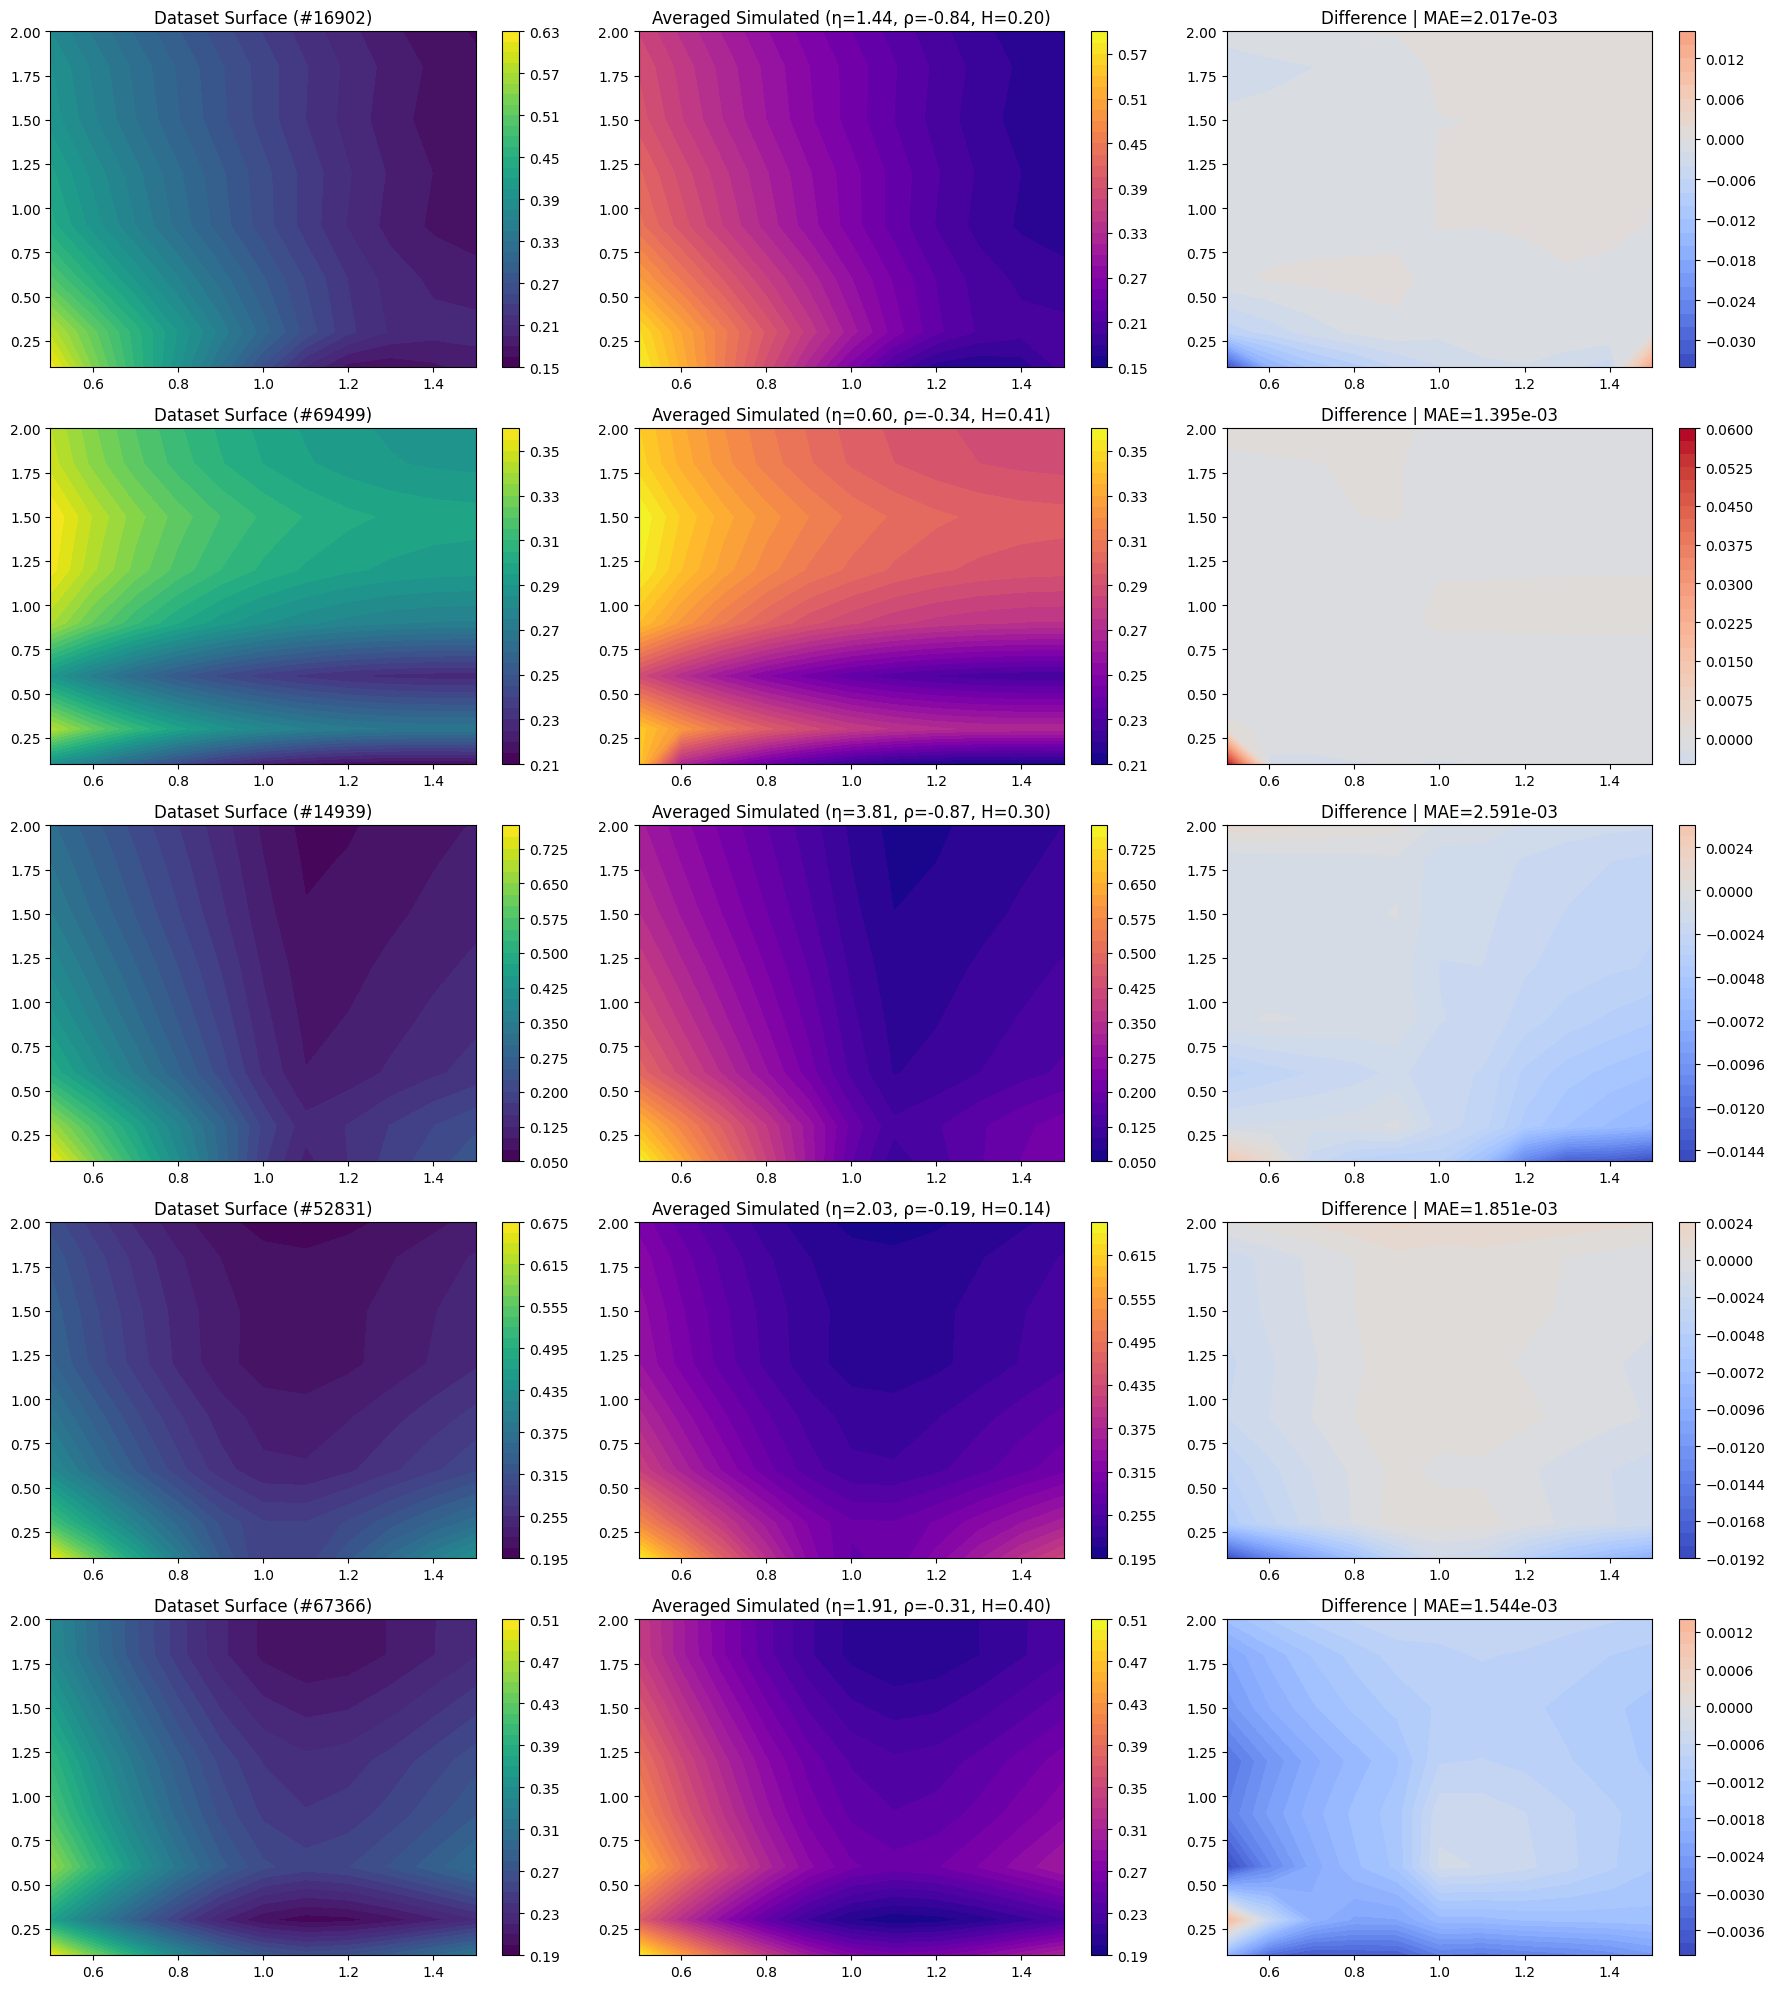

Comparison summary (averaged over seeds):
Idx 16902 | η=1.435, ρ=-0.842, H=0.201 | MAE=2.017e-03
Idx 69499 | η=0.601, ρ=-0.338, H=0.410 | MAE=1.395e-03
Idx 14939 | η=3.814, ρ=-0.875, H=0.299 | MAE=2.591e-03
Idx 52831 | η=2.031, ρ=-0.192, H=0.136 | MAE=1.851e-03
Idx 67366 | η=1.912, ρ=-0.310, H=0.403 | MAE=1.544e-03


In [1]:
import sys, os, gzip
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from generation.surface_generation import generate_fixed_surface, SimulationConfig

# ======================================================
# 1️⃣ Load data
# ======================================================

f = gzip.GzipFile("../OriginalCode/TrainrBergomiTermStructure.txt.gz", "r")
dat = np.load(f)
xx = dat[:, :11]
yy = dat[:, 11:]

strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
maturities = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])

cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=1)

# ======================================================
# 2️⃣ Define subset of parameter sets to test
# ======================================================
num_tests = 5        # number of parameter combinations to test
num_seeds = 1        # how many seeds to average over
np.random.seed(123467)
test_indices = np.random.choice(len(xx), num_tests, replace=False)

# ======================================================
# 3️⃣ Run simulations and compare
# ======================================================
results = []
fig, axs = plt.subplots(num_tests, 3, figsize=(18, 4 * num_tests))
if num_tests == 1:
    axs = axs.reshape(1, -1)

for row, idx in enumerate(test_indices):
    xi0_knots = xx[idx, :8]
    eta, rho, H = xx[idx, 8:11]
    param_set = {"eta": float(eta), "rho": float(rho), "H": float(H)}

    # Average several random seeds
    sim_surfaces = []
    for s in range(num_seeds):
        seed_val = 400 + s * 17  # any deterministic spacing
        surf = generate_fixed_surface(param_set, xi0_knots, strikes, maturities, cfg, seed=seed_val)
        sim_surfaces.append(surf["iv_surface"])
    sim_surface = np.mean(sim_surfaces, axis=0)

    # True dataset surface
    true_surface = yy[idx].reshape(len(maturities), len(strikes))

    diff = sim_surface - true_surface
    mae = np.mean(np.abs(diff))
    results.append({"idx": idx, "eta": eta, "rho": rho, "H": H, "mae": mae})

    K, T = np.meshgrid(strikes, maturities)

    # Plot
    c0 = axs[row, 0].contourf(K, T, true_surface, levels=30, cmap="viridis")
    axs[row, 0].set_title(f"Dataset Surface (#{idx})")
    plt.colorbar(c0, ax=axs[row, 0])

    c1 = axs[row, 1].contourf(K, T, sim_surface, levels=30, cmap="plasma")
    axs[row, 1].set_title(f"Averaged Simulated (η={eta:.2f}, ρ={rho:.2f}, H={H:.2f})")
    plt.colorbar(c1, ax=axs[row, 1])

    vmax = np.max(np.abs(diff))
    c2 = axs[row, 2].contourf(K, T, diff, levels=30, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axs[row, 2].set_title(f"Difference | MAE={mae:.3e}")
    plt.colorbar(c2, ax=axs[row, 2])

plt.tight_layout()
plt.show()

# ======================================================
# 4️⃣ Print summary stats
# ======================================================
print("Comparison summary (averaged over seeds):")
for r in results:
    print(f"Idx {r['idx']:>4} | η={r['eta']:.3f}, ρ={r['rho']:.3f}, H={r['H']:.3f} | MAE={r['mae']:.3e}")
